In [1]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

cm = confusion_matrix(y, clusters)
cm

array([[ 0, 50,  0],
       [39,  0, 11],
       [14,  0, 36]])

In [4]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(y, clusters)
nmi = normalized_mutual_info_score(y, clusters)

ari, nmi

(0.6201351808870379, np.float64(0.659486892724918))

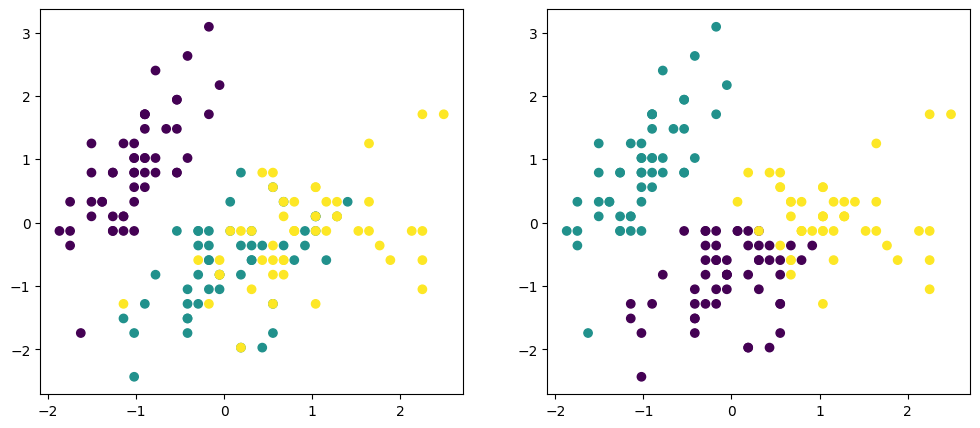

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)

plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)

plt.show()

In [6]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=5)
db_clusters = dbscan.fit_predict(X_scaled)

set(db_clusters)

{np.int64(-1), np.int64(0), np.int64(1)}

In [7]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(n_clusters=3)
agg_clusters = agglo.fit_predict(X_scaled)

set(agg_clusters)

{np.int64(0), np.int64(1), np.int64(2)}

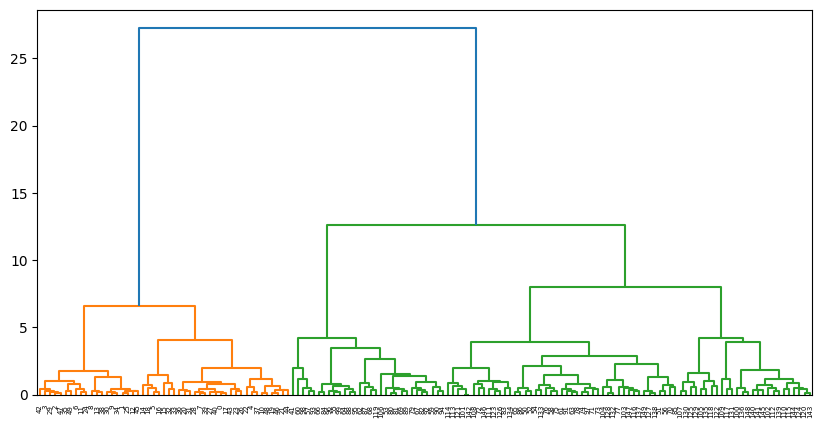

In [8]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.show()

In [9]:
from sklearn.metrics import adjusted_rand_score

ari_agg = adjusted_rand_score(y, agg_clusters)
ari_agg

0.6153229932145449

In [10]:
import numpy as np

def kmeans(X, k, max_iter=100):
    np.random.seed(42)
    indices = np.random.choice(len(X), k, replace=False)
    centroids = X[indices]

    for _ in range(max_iter):
        distances = np.linalg.norm(X[:, None] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        new_centroids = np.array([
            X[labels == i].mean(axis=0) if len(X[labels == i]) > 0 else centroids[i]
            for i in range(k)
        ])

        if np.all(centroids == new_centroids):
            break

        centroids = new_centroids

    return labels, centroids

In [11]:
labels_scratch, centroids_scratch = kmeans(X_scaled, 3)
labels_scratch[:10], centroids_scratch

(array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 array([[-0.01139555, -0.87600831,  0.37707573,  0.31115341],
        [-1.01457897,  0.85326268, -1.30498732, -1.25489349],
        [ 1.16743407,  0.14530299,  1.00302557,  1.0300019 ]]))

In [12]:
from sklearn.metrics import silhouette_score

silhouette_score(X_scaled, clusters)

np.float64(0.45994823920518635)